In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [3]:
np.random.seed(1)
m=100
x1=10*np.random.rand(m,1)-6
y=10+6*x1+5*x1**2+30*np.random.randn(m,1)

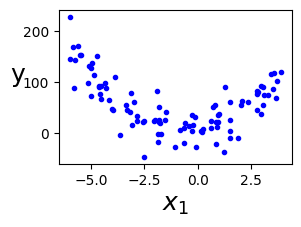

In [4]:
plt.figure(figsize=(3,2))
plt.plot(x1,y,"b.")
plt.xlabel("$x_1$",fontsize=18)
plt.ylabel("y",rotation=0,fontsize=18)
plt.show()

In [7]:
from sklearn.preprocessing import PolynomialFeatures
poly=PolynomialFeatures(degree=2,include_bias=False)
x1_p=poly.fit_transform(x1)

In [8]:
x1[0],x1_p[0]

(array([-1.82977995]), array([-1.82977995,  3.34809468]))

In [9]:
from sklearn.preprocessing import StandardScaler
scal=StandardScaler()
x1_ps=scal.fit_transform(x1_p)

In [10]:
from sklearn.linear_model import LinearRegression
poly_reg=LinearRegression()
poly_reg.fit(x1_ps,y)

LinearRegression()

In [11]:
poly_reg.intercept_,poly_reg.coef_

(array([55.51681743]), array([[17.42161695, 54.04329404]]))

In [12]:
from sklearn.linear_model import SGDRegressor
sgd_reg=SGDRegressor()
sgd_reg.fit(x1_ps,y.ravel())

SGDRegressor()

In [13]:
sgd_reg.intercept_,sgd_reg.coef_

(array([55.50302123]), array([16.70102324, 53.27843295]))

In [14]:
x_new=([[-5],[1]])
x_new_p=poly.transform(x_new)
x_new_ps=scal.transform(x_new_p)

In [15]:
poly_reg.predict(x_new_ps)

array([[113.63626971],
       [ 19.87706932]])

In [16]:
sgd_reg.predict(x_new_ps)

array([113.42124401,  20.02290533])

In [17]:
from sklearn.pipeline import Pipeline

In [18]:
pip_reg=Pipeline([('poly',PolynomialFeatures(degree=2,include_bias=False)),
                  ("scal",StandardScaler()),
                  ("poly_reg",LinearRegression())])

In [19]:
pip_reg.fit(x1,y)

Pipeline(steps=[('poly', PolynomialFeatures(include_bias=False)),
                ('scal', StandardScaler()), ('poly_reg', LinearRegression())])

In [20]:
pip_reg['poly_reg'].intercept_,pip_reg['poly_reg'].coef_

(array([55.51681743]), array([[17.42161695, 54.04329404]]))

In [21]:
x_new=([[-5],[1]])
pip_reg.predict(x_new)

array([[113.63626971],
       [ 19.87706932]])

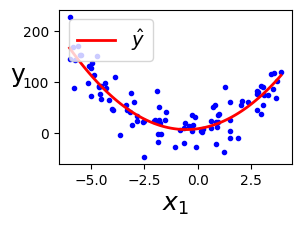

In [23]:
plt.figure(figsize=(3,2))

x1s=np.linspace(x1.min(),x1.max(),100).reshape(-1,1)
y_pred=pip_reg.predict(x1s)

plt.plot(x1,y,"b.")
plt.plot(x1s,y_pred,"r-",linewidth=2,label="$\hat y$")

plt.xlabel("$x_1$",fontsize=18)
plt.ylabel("y",rotation=0,fontsize=18)
plt.legend(loc="upper left",fontsize=14)
plt.show()